In [ ]:
!pip3 install pyspark

In [ ]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("CN7030_Multiclassification_using_the_Customer_Segmentation_Dataset") \
                            .master("local[*]").getOrCreate()

Loading dataset

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import file titled Customer Segmentation from my Google Drive

df = spark.read.csv("/content/drive/MyDrive/CN7030 - Machine Learning on Big Data (T2)/Labs/Week 5 Lab - Multiclassification and Ensemble Learning - Thursday 4th March/customer_segmentation_dataset.csv", header=True, inferSchema=True)

In [ ]:
df.show()

+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      High Value|
| 37|        94910|            85|               15|                 31|      High Value|
| 29|        83134|            64|               12|                  8|    Medium Value|
| 46|        52488|            81|               14|                 39|      High Value|
| 50|        90449|            22|               15|                  8|       Low Value|
| 68|     

In [ ]:
# show schema

df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
# number of rows

print ("Total Records", df.count())

Total Records 2000000


In [ ]:
# number of columns

print ("Total Columns", len(df.columns))

# names of columns

df.columns

Total Columns 6


['age',
 'annual_income',
 'spending_score',
 'years_as_customer',
 'number_of_purchases',
 'customer_segment']

In [ ]:
# import the vector assembler

from pyspark.ml.linalg  import Vectors
from pyspark.ml.feature import VectorAssembler

# convert all columns into Spark feature vectors

vector_assembler = VectorAssembler(inputCols = ["age", "annual_income", "spending_score", "years_as_customer", "number_of_purchases"], outputCol = "features")

In [ ]:
df_temp = vector_assembler.transform(df)

df_temp.show()

+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|            features|
+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+
| 22|       113441|            19|                2|                 44|       Low Value|[22.0,113441.0,19...|
| 47|        85415|            74|                7|                 11|    Medium Value|[47.0,85415.0,74....|
| 60|        78075|            18|               19|                 37|       Low Value|[60.0,78075.0,18....|
| 44|        89388|            84|               10|                 15|      High Value|[44.0,89388.0,84....|
| 37|        94910|            85|               15|                 31|      High Value|[37.0,94910.0,85....|
| 29|        83134|            64|               12|                  8|    Medium Value|[29.0,83134.0,64....|
|

In [ ]:
# delete the columns we do not need

df = df_temp.drop("age", "annual_income", "spending_score", "years_as_customer", "number_of_purchases")

In [ ]:
df.show()

+----------------+--------------------+
|customer_segment|            features|
+----------------+--------------------+
|       Low Value|[22.0,113441.0,19...|
|    Medium Value|[47.0,85415.0,74....|
|       Low Value|[60.0,78075.0,18....|
|      High Value|[44.0,89388.0,84....|
|      High Value|[37.0,94910.0,85....|
|    Medium Value|[29.0,83134.0,64....|
|      High Value|[46.0,52488.0,81....|
|       Low Value|[50.0,90449.0,22....|
|      High Value|[68.0,32563.0,99....|
|       Low Value|[67.0,117849.0,1....|
|    Medium Value|[30.0,37019.0,70....|
|       Low Value|[56.0,123133.0,21...|
|    Medium Value|[61.0,37340.0,72....|
|      High Value|[43.0,120000.0,88...|
|    Medium Value|[38.0,115658.0,51...|
|    Medium Value|[33.0,53169.0,73....|
|    Medium Value|[20.0,121342.0,74...|
|      High Value|[68.0,125552.0,76...|
|       Low Value|[60.0,95500.0,38....|
|      High Value|[37.0,64819.0,98....|
+----------------+--------------------+
only showing top 20 rows


In [ ]:
# import StringIndexer

from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(inputCol="customer_segment", outputCol="label")

df = label_indexer.fit(df).transform(df)

In [ ]:
df.select("customer_segment", "label").distinct().show()

+----------------+-----+
|customer_segment|label|
+----------------+-----+
|      High Value|  2.0|
|    Medium Value|  1.0|
|       Low Value|  0.0|
+----------------+-----+



In [ ]:
# split the dataset into training and testing

# 70% training data and 30% testing data

(trainingData, testData) = df.randomSplit([0.7, 0.3])

Multiclassification using Decision Trees

In [ ]:
# multiclassification using Decision Trees

from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

decision_tree = DecisionTreeClassifier(labelCol="label", featuresCol="features", impurity="entropy", maxDepth=5, seed=42)

model = decision_tree.fit(trainingData)

predictions = model.transform(testData)

In [ ]:
# evaluate the accuracy of the predictor

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

In [ ]:
accuracy = evaluator.evaluate(predictions)

print("Test accuracy =  " , accuracy)

Test accuracy =   0.9899684985880974


In [ ]:
print(model.toDebugString)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_1bbf7ed8b745, depth=2, numNodes=5, numClasses=3, numFeatures=5
  If (feature 2 <= 50.5)
   Predict: 0.0
  Else (feature 2 > 50.5)
   If (feature 2 <= 74.5)
    Predict: 1.0
   Else (feature 2 > 74.5)
    Predict: 2.0



Multiclassification using Logistic Regression

In [ ]:
# multiclassification using Logistic Regression

from pyspark.ml.classification import LogisticRegression

from pyspark.ml.classification import OneVsRest

In [ ]:
train, test = df.randomSplit([0.7, 0.3])

log_reg = LogisticRegression(maxIter=10, featuresCol="features",
                        labelCol='label')

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler

# instantiate StandardScaler to define 'stdScaler', outputting to a new column

stdScaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

ovr = OneVsRest(classifier=log_reg,
                labelCol='label',
                featuresCol='scaledFeatures')

# construct the pipeline with the instantiated StandardScaler and OneVsRest

pipeline_ovr = Pipeline(stages=[stdScaler, ovr])

pipelineModel_ovr = pipeline_ovr.fit(train)

In [ ]:
predictionsovr = pipelineModel_ovr.transform(test)

evaluator = MulticlassClassificationEvaluator(
labelCol="label", predictionCol="prediction",
metricName="accuracy")

accuracy = evaluator.evaluate(predictionsovr)

print("Test accuracy =  " , accuracy)

Test accuracy =   0.9728262952416024


Confusion Matrix

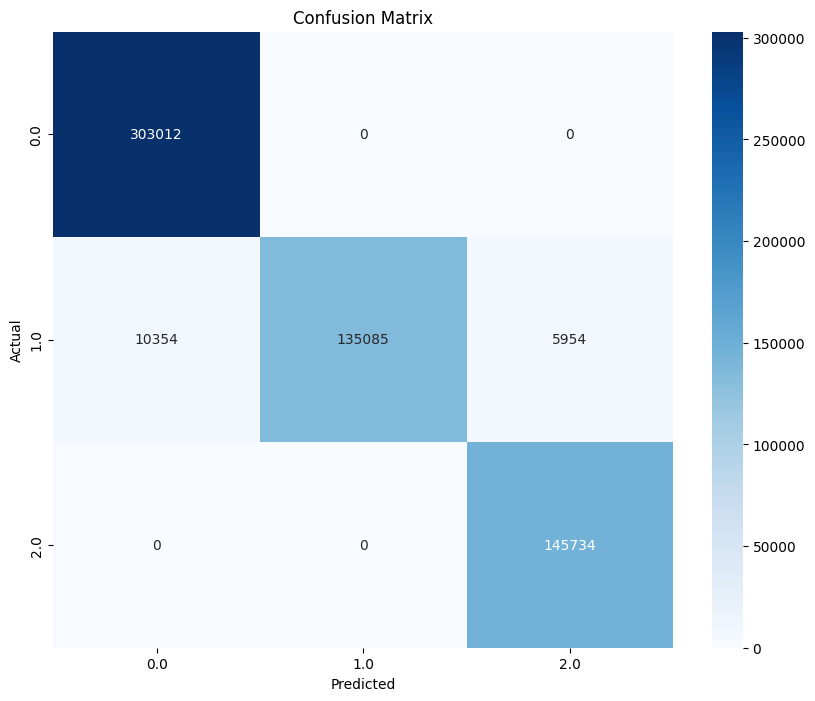

In [ ]:
import pyspark
from sklearn.metrics import confusion_matrix
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# create multiclassmetrics object and convert to Pandas dataframe for easier manipulation

prediction_and_labels = predictionsovr.select("prediction", "label").toPandas()

confusion_matrix = pd.crosstab(prediction_and_labels['label'], prediction_and_labels['prediction'], rownames=['Actual'], colnames=['Predicted'])

# plot the confusion matrix using Seaborn and Matplotlib

plt.figure(figsize=(10, 8))

sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

accuracy = evaluator.evaluate(predictionsovr)

print("Test accuracy =  " , accuracy)

Test accuracy =   0.9728262952416024
